In [1]:
import sys
sys.path.insert(0, '../')
from plotting import *
setup_plotting()
import numpy as np
from scipy import stats, optimize, special
import matplotlib.pyplot as plt

## Canonical Examples

In this section, we give some canonical examples of how the EM algorithm can be used to estimate model parameters. These examples are simple enough that they can be solved using more direct methods, but they are nevertheless useful for demonstrating how to set up the two-step EM algorithm in various scenarios.

### 4.2.1 Two-Part Normal Mixture Model

Suppose we have data $ y_1,\dots,y_n $ that are sampled independently from a two-part mixture of Normals model with density 

$$
f(y\mid\theta)=\lambda\varphi(y\mid\mu_1,\sigma_1^2) + (1-\lambda)\varphi(y\mid\mu_2,\sigma_2^2)
$$

 where $\varphi(y\mid\mu,\sigma^2)$ is the Normal density with mean $\mu $ and variance $\sigma^2 $. The unknown parameter vector is $\theta = (\mu_1,\mu_2,\sigma_1^2,\sigma_2^2, \lambda)$ and the log-likelihood 

$$
\log f(y_1,\dots,y_n\mid\theta)=\log \sum_{i=1}^n \lambda\varphi(y_i\mid\mu_1,\sigma_1) + (1-\lambda)\varphi(y_i\mid\mu_2,\sigma_2)
$$

 This problem is reasonably simple enough that it could be solved using a direct optimization method like Newton’s method, but the EM algorithm provides a nice stable approach to finding the optimum. The art of applying the EM algorithm is coming up with a useful complete data model. In this example, the approach is to hypothesize that each observation comes from one of two populations parameterized $(\mu_1, \sigma_1^2)$ $(\mu_2,\sigma^2_2)$, respectively. The “missing data” in this case are the labels identifying which observation came from which population. Therefore, we assert that there are missing data $ z_1,\dots,z_n $ such that $ z_i\sim\text{Bernoulli}(\lambda).$ When $ z_i=1 $, $ y_i $ comes from population 1 and when $ z_i=0 $, $ y_i $ comes from population 2. The idea is then that the data are sampled in two stages. First we sample $ z_i $ to see which population the data come from and then given $ z_i $, we can sample $ y_i $ from the appropriate Normal distribution. The joint density of the observed and missing data, i.e. the complete data density, is then 

$$
g(y,z\mid\theta)=\varphi(y\mid\mu_1,\sigma_1^2)^{z}\varphi(y\mid\mu_2,\sigma^2_2)^{1-z}\lambda^z(1-\lambda)^{1-z}
$$

 It’s easy to show that 1 $\sum_{z=0}^1 g(y, z\mid\theta) = f(y\mid\theta)$ so that when we “integrate” out the missing data, we get the observed data density. The complete data log-likelihood is then 

$$
\log g(y, z\mid\theta) =\sum_{i=1}^nz_i\log\varphi(y_i\mid\mu_1,\sigma^2_1) +(1-z_i)\log\varphi(y_i\mid\mu_2,\sigma^2_2) +z_i\log\lambda +(1-z_i)\log(1-\lambda)
$$

 Note that this function is nice and linear in the missing data $ z_i $. To evaluate $ Q(\theta\mid\theta_0)$ function we need to take the expectation of the above expression with respect to the missing data density $ h(z\mid y, \theta)$. But what is that? The missing data density will be proportional to the complete data density, so that

$\begin{eqnarray*}h(z\mid y,\theta)& \propto &\varphi(y\mid\mu_1,\sigma_1^2)^z\varphi(y\mid\mu_2,\sigma_2^2)^{1-z}\lambda^z(1-\lambda)^{1-z}\\& = &(\lambda \varphi(y\mid\mu_1,\sigma_1^2))^z((1-\lambda)\varphi(y\mid\mu_2,\sigma_2^2))^{1-z}\\& = &\text{Bernoulli}\left(\frac{\lambda \varphi(y\mid\mu_1,\sigma_1^2)}{\lambda \varphi(y\mid\mu_1,\sigma_1^2) + (1-\lambda)\varphi(y\mid\mu_2,\sigma_2^2)}\right)\end{eqnarray*}$ From this, what we need to compute $ Q()$ function is $\pi_i = \mathbb{E}[z_i\mid y_i, \theta_0]$. Given that, wen then compute $ Q()$ function in the E-step.

$\begin{eqnarray*}Q(\theta\mid\theta_0)& = &\mathbb{E}\left[\sum_{i=1}^nz_i\log\varphi(y\mid\mu_1,\sigma_1^2)+ (1-z_i)\log\varphi(y\mid\mu_2,\sigma_2^2)+ z_i\log\lambda + (1-z_i)\log(1-\lambda)\right]\\& = &\sum_{i=1}^n\pi_i\log\varphi(y\mid\mu_1,\sigma_1^2)+ (1-\pi_i)\varphi(y\mid\mu_2,\sigma_2^2)+ \pi_i\log\lambda+ (1-\pi_i)\log(1-\lambda)\\& = &\sum_{i=1}^n\pi_i\left[-\frac{1}{2}\log 2\pi\sigma_1^2-\frac{1}{2\sigma_1^2}(y_i-\mu_1)^2\right]+ (1-\pi_i)\left[-\frac{1}{2}\log 2\pi\sigma_2^2-\frac{1}{2\sigma_2^2}(y_i-\mu_2)^2\right]\\& & + \pi_i\log\lambda + (1-\pi_i)\log(1-\lambda)\end{eqnarray*}$ In order to compute $\pi_i $, we will need to use the current estimates of $\mu_1, \sigma_1^2, \mu_2 $, and $\sigma_2^2 $(in addition to the data $ y_1,\dots, y_n $). We can then compute the gradient $ Q $ in order maximize it for the current iteration. After doing that we get the next values, which

$\begin{eqnarray*}\hat{\mu}_1 & = & \frac{\sum \pi_i y_i}{\sum \pi_i}\\\hat{\mu}_2 & = & \frac{\sum (1-\pi_i) y_i}{\sum 1-\pi_i}\\\hat{\sigma}_1^2 & = & \frac{\sum\pi_i(y_i-\mu_1)^2}{\sum\pi_i}\\\hat{\sigma}_2^2 & = & \frac{\sum(1-\pi_i)(y_i-\mu_2)^2}{\sum(1-\pi_i)}\\\hat{\lambda} & = & \frac{1}{n}\sum\pi_i\end{eqnarray*}$ Once we have these updated estimates, we can go back to the E-step and recompute $ Q $ function.

### 4.2.2 Censored Exponential Data

Suppose we have survival times $ x_1,\dots,x_n\sim\text{Exponential}(\lambda)$. However, we do not observe these survival times because some of them are censored at times $ c_1,\dots,c_n $. Because the censoring times are known, what we actually observe are the data $(\min(y_1, c_1), \delta_1),\dots,(\min(y_n,c_n),\delta_n)$, where $\delta=1 $ if $ y_i\leq c_i $ and $\delta=0 $ $ y_i $ is censored at time $ c_i $. The complete data density is simply the exponential distribution with rate parameter $\lambda $, 

$$
g(x_1,\dots,x_n\mid\lambda)=\prod_{i=1}^n\frac{1}{\lambda}\exp(-x_i/\lambda)
$$

 To do the E-step, we need to compute

$$Q(\lambda\mid\lambda_0) = \mathbb{E}[\log g(x_1,\dots,x_n\mid\lambda)\mid \mathbf{y}, \lambda_0]$$

We can divide the data into the observations that we fully observe ( $\delta_i=1 $) and those that are censored ( $\delta_i=0 $). For the censored data, their complete survival time is “missing”, so can denote the complete survival time $ z_i $. Given that, the $Q(\lambda\mid\lambda_0)$ function is

$$Q(\lambda\mid\lambda_0) = \mathbb{E}\left[\left.-n\log\lambda-\frac{1}{\lambda}\left[\sum_{i=1}^n\delta_i y_i + (1-\delta_i) z_i\right]\right|\mathbf{y},\lambda_0\right]$$

But what $\mathbb{E}[z_i\mid y_i,\lambda_0]$? Because we assume the underlying data are exponentially distributed, we can use the “memoryless” property of the exponential distribution. That is, given that we have survived until the censoring time $ c_i $, our expected survival time beyond that is simply $\lambda $. Because we don’t know $\lambda $ yet we can plug in our current best estimate. Now, for the E-step we have

$$Q(\lambda\mid\lambda_0) = -n\log\lambda - \frac{1}{\lambda}\left[\sum_{i=1}^n\delta_i y_i + (1-\delta_i)(c_i + \lambda_0)\right]$$

With the $Q$ function removed of missing data, we can execute the M-step and maximize the above function to get

$$\hat{\lambda} = \frac{1}{n}\left[\sum_{i=1}^n\delta_i y_i + (1-\delta_i)(c_i + \lambda_0)\right]$$

We can then update $\lambda_0 = \hat{\lambda}$ and go back and repeat the E-step.

In [2]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# Generate data from a 2-component normal mixture
n = 300
true_lambda = 0.4
true_mu1, true_mu2 = -2.0, 2.5
true_sig1, true_sig2 = 0.8, 1.2

z = rng.binomial(1, true_lambda, n)
y = np.where(z == 1,
             rng.normal(true_mu1, true_sig1, n),
             rng.normal(true_mu2, true_sig2, n))

def em_normal_mixture(y, max_iter=200, tol=1e-8):
    """EM algorithm for 2-component normal mixture."""
    n = len(y)
    # Initialise with k-means-style split
    lam = 0.5
    mu1, mu2 = np.percentile(y, 25), np.percentile(y, 75)
    sig1, sig2 = np.std(y), np.std(y)
    log_lik_history = []

    for _ in range(max_iter):
        # E-step: compute responsibilities
        p1 = lam * stats.norm.pdf(y, mu1, sig1)
        p2 = (1 - lam) * stats.norm.pdf(y, mu2, sig2)
        total = p1 + p2
        pi = p1 / total          # P(z_i=1 | y_i, theta)

        # Log-likelihood
        ll = np.sum(np.log(total))
        log_lik_history.append(ll)

        # M-step: update parameters
        sum_pi = pi.sum()
        lam_new = sum_pi / n
        mu1_new = (pi * y).sum() / sum_pi
        mu2_new = ((1 - pi) * y).sum() / (n - sum_pi)
        sig1_new = np.sqrt((pi * (y - mu1_new)**2).sum() / sum_pi)
        sig2_new = np.sqrt(((1 - pi) * (y - mu2_new)**2).sum() / (n - sum_pi))

        if abs(lam_new - lam) < tol:
            lam, mu1, mu2, sig1, sig2 = lam_new, mu1_new, mu2_new, sig1_new, sig2_new
            log_lik_history.append(np.sum(np.log(
                lam*stats.norm.pdf(y, mu1, sig1) + (1-lam)*stats.norm.pdf(y, mu2, sig2))))
            break
        lam, mu1, mu2, sig1, sig2 = lam_new, mu1_new, mu2_new, sig1_new, sig2_new

    return dict(lam=lam, mu1=mu1, mu2=mu2, sig1=sig1, sig2=sig2,
                log_lik=log_lik_history)

result = em_normal_mixture(y)
print("Estimated parameters:")
print(f"  lambda = {result['lam']:.3f}  (true: {true_lambda})")
print(f"  mu1    = {result['mu1']:.3f}  (true: {true_mu1})")
print(f"  mu2    = {result['mu2']:.3f}  (true: {true_mu2})")
print(f"  sigma1 = {result['sig1']:.3f}  (true: {true_sig1})")
print(f"  sigma2 = {result['sig2']:.3f}  (true: {true_sig2})")
print(f"  EM converged in {len(result['log_lik'])} iterations")

Estimated parameters:
  lambda = 0.386  (true: 0.4)
  mu1    = -2.046  (true: -2.0)
  mu2    = 2.533  (true: 2.5)
  sigma1 = 0.821  (true: 0.8)
  sigma2 = 1.170  (true: 1.2)
  EM converged in 33 iterations


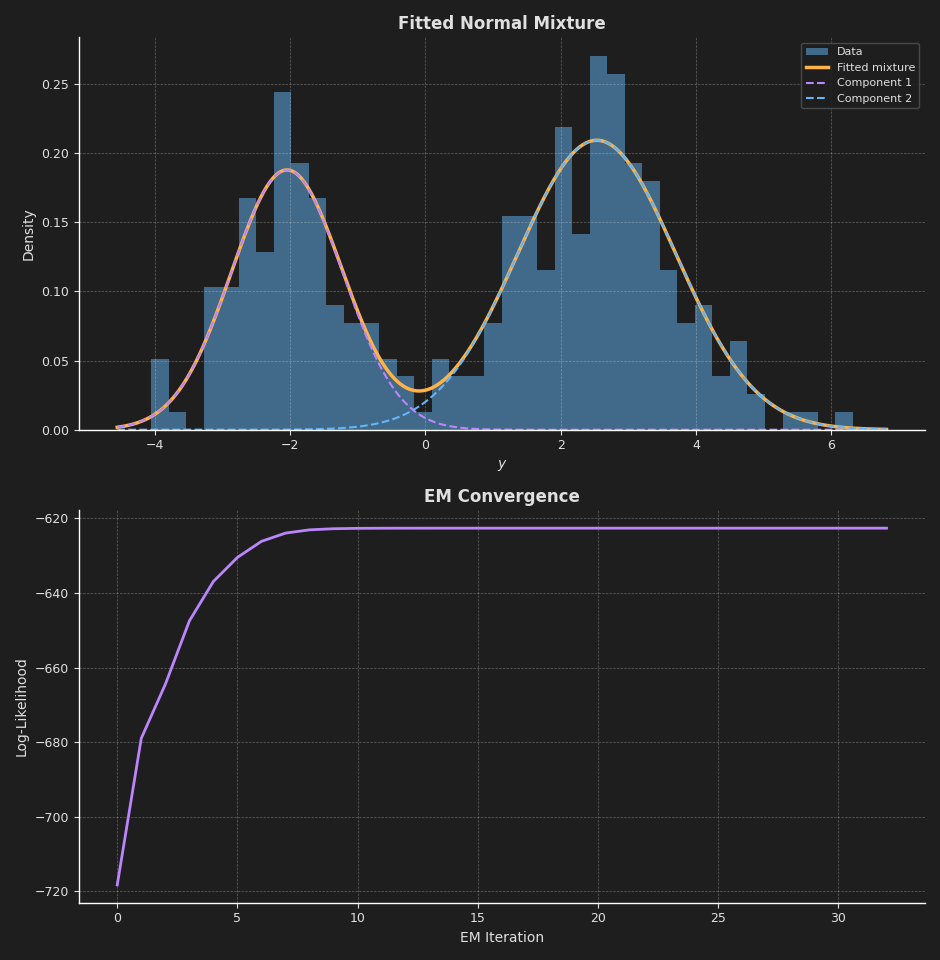

In [3]:
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE_2PANEL)

# Left: data histogram + fitted mixture
ax = axes[0]
xs = np.linspace(y.min() - 0.5, y.max() + 0.5, 500)
fitted = (result['lam'] * stats.norm.pdf(xs, result['mu1'], result['sig1'])
        + (1 - result['lam']) * stats.norm.pdf(xs, result['mu2'], result['sig2']))

ax.hist(y, bins=40, density=True, color=C['blue'], alpha=0.5, label='Data')
ax.plot(xs, fitted, color=C['orange'], lw=2.5, label='Fitted mixture')
ax.plot(xs, result['lam'] * stats.norm.pdf(xs, result['mu1'], result['sig1']),
        color=C['purple'], lw=1.5, ls='--', label='Component 1')
ax.plot(xs, (1-result['lam']) * stats.norm.pdf(xs, result['mu2'], result['sig2']),
        color=C['blue'], lw=1.5, ls='--', label='Component 2')
ax.set_xlabel('$y$')
ax.set_ylabel('Density')
ax.set_title('Fitted Normal Mixture')
ax.legend(fontsize=8)

# Right: log-likelihood convergence
ax = axes[1]
ax.plot(result['log_lik'], color=C['purple'], lw=2)
ax.set_xlabel('EM Iteration')
ax.set_ylabel('Log-Likelihood')
ax.set_title('EM Convergence')
plt.tight_layout()

### 4.2.2 Censored Exponential Data

Now we implement the EM algorithm for censored exponential survival data. The E-step uses the memoryless property of the exponential distribution to impute the expected complete survival time for censored observations.

Fraction censored: 40.0%
EM estimate of mean:  2.4154
True mean:            2.0000
Naive mean (ignoring censoring): 1.4492
Converged in 27 iterations


<>:47: SyntaxWarning: invalid escape sequence '\h'
<>:47: SyntaxWarning: invalid escape sequence '\h'
/var/folders/sx/j6nc9lsx5bb2r3zpb6hx7vdm0000gn/T/ipykernel_78366/140785703.py:47: SyntaxWarning: invalid escape sequence '\h'
  ax.set_ylabel('Estimated Mean $\hat{\lambda}$')


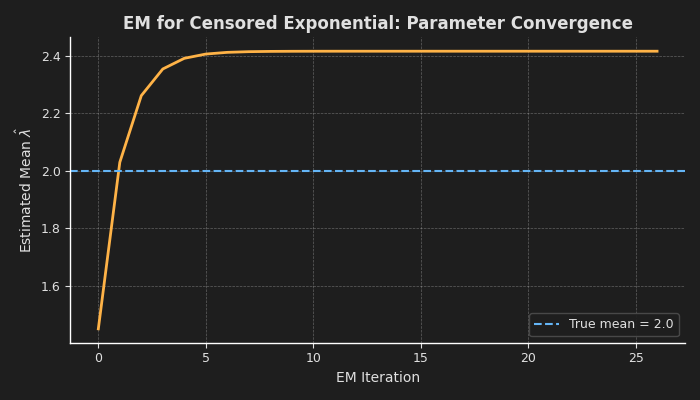

In [4]:
def em_censored_exponential(y_obs, delta, max_iter=500, tol=1e-10):
    """
    EM for censored exponential data.
    y_obs : observed times (min(x_i, c_i))
    delta : 1 if event observed, 0 if censored
    """
    lam = np.mean(y_obs)   # initial estimate (biased but simple)
    history = [lam]

    for _ in range(max_iter):
        # E-step: E[x_i | y_i, lam]
        #   = y_i         if delta_i = 1  (fully observed)
        #   = c_i + lam   if delta_i = 0  (censored: memoryless property)
        e_x = np.where(delta == 1, y_obs, y_obs + lam)

        # M-step: lam_new = mean of expected complete data
        lam_new = e_x.mean()
        history.append(lam_new)

        if abs(lam_new - lam) < tol:
            break
        lam = lam_new

    return lam_new, history

# Simulate censored exponential data
rng2 = np.random.default_rng(99)
true_rate = 2.0          # true mean = 1/rate... using mean parameterisation
n_surv = 200
x_true = rng2.exponential(scale=true_rate, size=n_surv)   # true survival times
c = rng2.uniform(0.5, 4.0, size=n_surv)                   # censoring times
y_surv = np.minimum(x_true, c)
delta_surv = (x_true <= c).astype(float)

print(f"Fraction censored: {1 - delta_surv.mean():.1%}")

lam_hat, lam_history = em_censored_exponential(y_surv, delta_surv)
print(f"EM estimate of mean:  {lam_hat:.4f}")
print(f"True mean:            {true_rate:.4f}")
print(f"Naive mean (ignoring censoring): {y_surv.mean():.4f}")
print(f"Converged in {len(lam_history)} iterations")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lam_history, color=C['orange'], lw=2)
ax.axhline(true_rate, color=C['blue'], ls='--', lw=1.5, label=f'True mean = {true_rate}')
ax.set_xlabel('EM Iteration')
ax.set_ylabel('Estimated Mean $\hat{\lambda}$')
ax.set_title('EM for Censored Exponential: Parameter Convergence')
ax.legend()
plt.tight_layout()